# ERA5

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [2]:
from src.datasources import era5, cerf, codab
from src.constants import *

from src.utils import blob_utils

In [3]:
months_of_interest = [7, 8, 9]

In [4]:
adm1 = codab.load_codab_from_blob(admin_level=1)
adm2 = codab.load_codab_from_blob(admin_level=2)
adm3 = codab.load_codab_from_blob(admin_level=3)

In [5]:
cerf_df = cerf.load_cerf()

In [6]:
cerf_df

,year,month,ADM_PCODE,admin_level
0,2009,9,BF130004,3
1,2010,7,BF52,1
2,2010,7,BF56,1
3,2010,7,BF54,1
4,2010,7,BF49,1
5,2010,7,BF55,1


In [7]:
era5_adm2_df = era5.load_era5_monthly(adm_level=2)
era5_adm1_df = era5.load_era5_monthly(adm_level=1)

In [8]:
era5_adm0_df = era5.load_era5_monthly(adm_level=0)

In [20]:
era5_df = era5_adm2_df.copy()

In [21]:
def calculate_rp(group, col_name):
    group[f"rank_{col_name}"] = group[col_name].rank(ascending=False)
    group[f"rp_{col_name}"] = (len(group) + 1) / group[f"rank_{col_name}"]
    return group

In [24]:
era5_adm0_df.dtypes

ADM0_PCODE            object
valid_date    datetime64[ns]
mean                 float64
median               float64
min                  float64
max                  float64
count                  int64
sum                  float64
std                  float64
dtype: object

<Axes: xlabel='valid_date'>

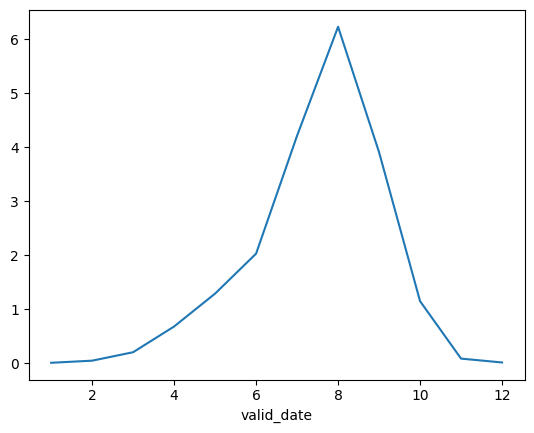

In [26]:
era5_adm0_df.groupby(era5_adm0_df["valid_date"].dt.month)["mean"].mean().plot()

In [14]:
era5_adm0_jas_df = era5_adm0_df[
    era5_adm0_df["valid_date"].dt.month.isin(months_of_interest)
]

era5_adm0_jas_df = (
    era5_adm0_jas_df.groupby(
        ["ADM0_PCODE", era5_adm0_jas_df["valid_date"].dt.year.rename("year")]
    )
    .sum(numeric_only=True)
    .reset_index()
)

era5_adm0_jas_df

era5_adm0_jas_df = (
    era5_adm0_jas_df.groupby("ADM0_PCODE")
    .apply(calculate_rp, col_name="mean", include_groups=False)
    .reset_index()
    .drop(columns=["level_1"])
)
era5_adm0_jas_df.sort_values("rank_mean")

,ADM0_PCODE,year,mean,median,min,max,count,sum,std,rank_mean,rp_mean
39,BF,2020,18.491999,18.280029,4.312515,37.986756,27216,167759.426,6.879705,1.0,45.000000
18,BF,1999,18.480406,18.272400,9.002686,34.709930,27216,167654.234,4.396305,2.0,22.500000
43,BF,2024,17.929884,17.559051,4.981995,34.154892,27216,162659.917,5.803317,3.0,15.000000
7,BF,1988,17.663473,17.461776,6.412506,34.069062,27216,160243.029,5.453598,4.0,11.250000
29,BF,2010,17.477741,16.437531,5.884170,33.361435,27216,158558.068,6.367418,5.0,9.000000
5,BF,1986,17.174399,17.641067,4.436493,32.649994,27216,155806.144,5.188403,6.0,7.500000
34,BF,2015,17.102825,17.095566,5.592346,33.052444,27216,155156.835,5.012597,7.0,6.428571
13,BF,1994,17.041998,17.635345,6.063461,28.654099,27216,154605.001,3.709288,8.0,5.625000
22,BF,2003,16.870435,16.218186,6.628036,31.793595,27216,153048.587,5.124123,9.0,5.000000
31,BF,2012,16.803931,16.494751,7.041931,30.822754,27216,152445.259,4.149163,10.0,4.500000


In [15]:
era5_adm1_jas_df = era5_adm1_df[
    era5_adm1_df["valid_date"].dt.month.isin(months_of_interest)
]
era5_adm1_jas_df = (
    era5_adm1_jas_df.groupby(
        ["ADM1_PCODE", era5_adm1_jas_df["valid_date"].dt.year.rename("year")]
    )
    .sum(numeric_only=True)
    .reset_index()
)
era5_adm1_jas_df = (
    era5_adm1_jas_df.groupby("ADM1_PCODE")
    .apply(calculate_rp, col_name="mean", include_groups=False)
    .reset_index()
    .drop(columns=["level_1"])
)
era5_adm1_jas_df

,ADM1_PCODE,year,mean,median,min,max,count,sum,std,rank_mean,rp_mean
0,BF13,1981,18.984014,19.365311,15.356064,22.096634,297,1879.41745,1.774037,3.0,15.000000
1,BF13,1982,9.704686,9.780884,8.445740,11.520386,297,960.76391,0.836678,44.0,1.022727
2,BF13,1983,10.107368,10.087967,8.569717,11.436462,297,1000.62941,0.649244,43.0,1.046512
3,BF13,1984,11.441702,11.634827,9.233475,13.538360,297,1132.72856,1.204977,37.0,1.216216
4,BF13,1985,14.642195,14.627457,12.453079,16.819000,297,1449.57734,1.318450,22.0,2.045455
...,...,...,...,...,...,...,...,...,...,...,...
567,BF57,2020,21.373748,21.251679,14.961243,29.062271,1647,11734.18830,3.311969,6.0,7.500000
568,BF57,2021,16.013019,16.595840,10.942459,20.086288,1647,8791.14710,2.284791,35.0,1.285714
569,BF57,2022,21.421766,21.415710,15.634537,28.902054,1647,11760.54960,2.962552,5.0,9.000000
570,BF57,2023,17.809887,18.316269,13.219833,22.830963,1647,9777.62790,2.685222,19.0,2.368421


In [16]:
rp_thresh = 3

triggered_df = era5_adm1_jas_df[era5_adm1_jas_df["rp_mean"] > rp_thresh]

unique_years = triggered_df["year"].nunique()
print(f"unique years: {unique_years}")
print(f"effective rp: {(44 + 1) / unique_years}")
print()

for pcode in [CENTRE1, CENTRENORD1, SAHEL1, EST1, NORD1, PLATEAUCENTRAL1]:
    display(triggered_df[triggered_df["ADM1_PCODE"] == pcode])

unique years: 28
effective rp: 1.6071428571428572



,ADM1_PCODE,year,mean,median,min,max,count,sum,std,rank_mean,rp_mean
0,BF13,1981,18.984014,19.365311,15.356064,22.096634,297,1879.41745,1.774037,3.0,15.000000
5,BF13,1986,18.867704,18.714905,15.668869,22.188187,297,1867.90277,1.750377,4.0,11.250000
7,BF13,1988,16.284230,16.355514,14.228821,19.126893,297,1612.13877,1.053435,13.0,3.461538
8,BF13,1989,17.530422,17.900467,15.489578,19.615173,297,1735.51172,1.163042,8.0,5.625000
11,BF13,1992,16.319488,15.838623,14.337540,19.420623,297,1615.62922,1.200709,12.0,3.750000
13,BF13,1994,18.478162,18.665314,16.574859,20.366668,297,1829.33810,0.986637,6.0,7.500000
18,BF13,1999,17.461064,17.017365,15.323639,21.228790,297,1728.64534,1.428048,10.0,4.500000
20,BF13,2001,16.231999,16.632080,13.605118,18.070221,297,1606.96792,1.076158,14.0,3.214286
22,BF13,2003,17.187485,17.024994,13.912201,19.992829,297,1701.56102,1.621950,11.0,4.090909
34,BF13,2015,18.516136,18.507004,15.245438,23.004532,297,1833.09743,2.146901,5.0,9.000000


,ADM1_PCODE,year,mean,median,min,max,count,sum,std,rank_mean,rp_mean
176,BF49,1981,13.019066,12.487412,9.620666,18.768311,1971,8553.5259,1.963769,11.0,4.090909
181,BF49,1986,12.930813,12.962341,8.953095,18.056869,1971,8495.5442,1.742737,12.0,3.750000
183,BF49,1988,12.355200,11.926651,9.328842,17.271042,1971,8117.3667,1.878344,14.0,3.214286
184,BF49,1989,14.436423,13.935089,9.420395,19.706726,1971,9484.7297,2.507084,3.0,15.000000
187,BF49,1992,13.024895,13.078689,8.520126,18.932343,1971,8557.3559,2.230835,10.0,4.500000
189,BF49,1994,14.879503,14.675140,11.144638,18.999100,1971,9775.8327,1.810596,1.0,45.000000
194,BF49,1999,14.197218,14.045715,11.558533,17.881393,1971,9327.5720,1.322201,4.0,11.250000
195,BF49,2000,12.686952,12.407303,8.207321,17.978668,1971,8335.3270,2.186883,13.0,3.461538
198,BF49,2003,13.622055,13.553619,9.323120,17.187119,1971,8949.6900,1.552751,6.0,7.500000
207,BF49,2012,14.585994,14.171600,10.786056,19.485474,1971,9582.9985,1.917436,2.0,22.500000


,ADM1_PCODE,year,mean,median,min,max,count,sum,std,rank_mean,rp_mean
484,BF56,1981,10.421160,10.208130,6.969452,13.664246,3531,12265.7047,1.478882,5.0,9.000000
489,BF56,1986,9.687678,9.521484,4.436493,16.586303,3531,11402.3967,2.966776,10.0,4.500000
491,BF56,1988,10.196592,9.992600,6.412506,15.563965,3531,12001.3884,1.719197,7.0,6.428571
492,BF56,1989,9.629015,9.614945,4.955292,15.163421,3531,11333.3512,2.031872,11.0,4.090909
497,BF56,1994,11.144218,10.951996,6.063461,16.395569,3531,13116.7446,2.118418,3.0,15.000000
501,BF56,1998,10.192440,9.765625,7.291794,15.052795,3531,11996.5018,1.616034,8.0,5.625000
502,BF56,1999,13.887492,13.765335,9.698868,17.810822,3531,16345.5774,1.762502,1.0,45.000000
506,BF56,2003,10.409128,10.314941,6.696701,15.565872,3531,12251.5431,1.981433,6.0,7.500000
513,BF56,2010,10.762815,10.524750,5.884170,19.720077,3531,12667.8331,2.611410,4.0,11.250000
515,BF56,2012,12.781885,12.285233,7.041931,19.239425,3531,15044.2797,2.904188,2.0,22.500000


,ADM1_PCODE,year,mean,median,min,max,count,sum,std,rank_mean,rp_mean
313,BF52,1986,15.688417,16.151428,9.557724,22.996902,4749,24834.7645,2.927749,8.0,5.625000
315,BF52,1988,16.581378,16.120911,10.683060,26.239395,4749,26248.3210,2.873167,5.0,9.000000
316,BF52,1989,14.496676,14.654159,9.258270,20.704270,4749,22948.2380,2.156765,12.0,3.750000
321,BF52,1994,17.210709,17.335892,11.878967,22.754669,4749,27244.5526,2.090699,4.0,11.250000
326,BF52,1999,17.315790,17.377853,11.871338,24.709702,4749,27410.8945,2.671185,2.0,22.500000
330,BF52,2003,15.224006,14.720917,10.221481,23.578644,4749,24099.6024,2.596136,10.0,4.500000
337,BF52,2010,14.443605,13.534546,8.586883,25.333404,4749,22864.2271,3.896390,13.0,3.461538
339,BF52,2012,19.298651,19.491196,11.816025,29.960632,4749,30549.7650,4.074814,1.0,45.000000
342,BF52,2015,16.250700,15.810013,9.420395,25.812149,4749,25724.8567,3.586052,6.0,7.500000
343,BF52,2016,14.030391,13.736725,9.849548,19.048691,4749,22210.1080,2.100403,14.0,3.214286


,ADM1_PCODE,year,mean,median,min,max,count,sum,std,rank_mean,rp_mean
396,BF54,1981,14.018446,13.578415,9.120941,21.053314,1665,7780.2372,2.827684,9.0,5.000000
400,BF54,1985,13.527013,13.282776,10.421753,17.696380,1665,7507.4920,1.729289,12.0,3.750000
401,BF54,1986,15.028666,14.862061,9.138107,21.480560,1665,8340.9100,3.324054,5.0,9.000000
404,BF54,1989,13.536058,13.460159,9.756088,18.913269,1665,7512.5122,2.081279,11.0,4.090909
407,BF54,1992,13.124569,13.753891,8.209229,17.210007,1665,7284.1359,2.484165,14.0,3.214286
409,BF54,1994,15.126038,14.858246,10.677338,19.931793,1665,8394.9509,2.419679,4.0,11.250000
414,BF54,1999,16.197106,16.138077,12.363434,22.165298,1665,8989.3935,2.138491,3.0,15.000000
418,BF54,2003,13.541227,13.740540,8.964539,19.895554,1665,7515.3807,2.961453,10.0,4.500000
425,BF54,2010,14.411194,14.421463,11.255264,17.820358,1665,7998.2130,1.317945,8.0,5.625000
427,BF54,2012,14.903785,15.073776,10.503769,17.700195,1665,8271.6009,1.663778,6.0,7.500000


,ADM1_PCODE,year,mean,median,min,max,count,sum,std,rank_mean,rp_mean
440,BF55,1981,16.952623,16.498566,11.436462,23.206710,849,4797.59220,3.192136,8.0,5.625000
445,BF55,1986,17.419937,17.040253,13.139725,22.665024,849,4929.84210,1.949580,7.0,6.428571
447,BF55,1988,16.221339,16.132354,11.857987,20.891189,849,4590.63920,2.046002,11.0,4.090909
448,BF55,1989,17.599572,17.953872,13.353348,20.372390,849,4980.67860,1.756387,6.0,7.500000
451,BF55,1992,15.751478,15.836716,12.201309,19.805908,849,4457.66820,1.757494,12.0,3.750000
453,BF55,1994,17.779125,17.559051,15.117645,20.593643,849,5031.49220,1.212634,3.0,15.000000
457,BF55,1998,15.481922,15.373230,11.455536,18.716812,849,4381.38380,1.688293,13.0,3.461538
458,BF55,1999,16.808904,16.387940,13.406753,20.822525,849,4756.91980,1.847299,9.0,5.000000
474,BF55,2015,17.738578,17.856598,14.223099,23.649215,849,5020.01760,1.999222,4.0,11.250000
475,BF55,2016,18.245905,18.281936,12.760162,23.668289,849,5163.59130,2.409389,2.0,22.500000


In [17]:
era5_df["valid_date"].dt.year.nunique()

NameError: name 'era5_df' is not defined

In [18]:
era5_df = era5_df.merge(
    adm2[["ADM1_PCODE", "ADM2_PCODE", "ADM1_FR", "ADM2_FR"]]
)

NameError: name 'era5_df' is not defined

In [162]:
era5_adm1_df

,ADM1_PCODE,valid_date,mean,median,min,max,count,sum,std
71,BF13,1981-01-01,0.000559,0.000000,0.000000,0.005722,99,0.055313,0.000987
755,BF13,1981-02-01,0.000000,0.000000,0.000000,0.000000,99,0.000000,0.000000
768,BF13,1981-03-01,0.053136,0.041962,0.024796,0.139236,99,5.260467,0.032426
305,BF13,1981-04-01,0.702097,0.654221,0.329971,1.220703,99,69.507600,0.277356
318,BF13,1981-05-01,2.719263,2.740860,2.105713,3.671646,99,269.207000,0.325251
...,...,...,...,...,...,...,...,...,...
5935,BF57,2024-06-01,2.929625,2.882004,2.016068,3.582001,549,1608.364100,0.400634
5948,BF57,2024-07-01,5.429346,5.491257,3.181458,6.652832,549,2980.711000,0.909969
5961,BF57,2024-08-01,9.582707,9.294510,6.486893,12.647629,549,5260.906200,1.443478
5974,BF57,2024-09-01,6.558065,6.525040,4.962921,8.483887,549,3600.378000,0.971418


In [170]:
era5_adm1_rp_df = (
    era5_adm1_df.groupby(
        [era5_adm1_df["valid_date"].dt.month.rename("month"), "ADM1_PCODE"]
    )
    .apply(calculate_rp, col_name="mean", include_groups=False)
    .reset_index()
    .drop(columns=["level_2"])
)

In [174]:
era5_adm1_rp_df = era5_adm1_rp_df[
    era5_adm1_rp_df["month"].isin(months_of_interest)
]

In [280]:
rp_thresh = 3

triggered_df = (
    era5_adm1_rp_df[era5_adm1_rp_df["rp_mean"] > rp_thresh]
    .merge(adm1[["ADM1_PCODE", "ADM1_FR"]])
    .sort_values(["ADM1_FR", "month", "rank_mean"])
)

unique_years = triggered_df["valid_date"].dt.year.nunique()
print(f"unique years: {unique_years}")
print(f"effective rp: {(44 + 1) / unique_years}")
print()

for pcode in [CENTRE1, CENTRENORD1, SAHEL1, EST1, NORD1, PLATEAUCENTRAL1]:
    dff = triggered_df[triggered_df["ADM1_PCODE"] == pcode]
    unique_years_f = dff["valid_date"].dt.year.nunique()
    print(f"unique years: {unique_years_f}")
    print(f"effective rp: {(44 + 1) / unique_years_f}")
    display(triggered_df[triggered_df["ADM1_PCODE"] == pcode])

unique years: 40
effective rp: 1.125

unique years: 28
effective rp: 1.6071428571428572


,month,ADM1_PCODE,valid_date,mean,median,min,max,count,sum,std,rank_mean,rp_mean,ADM1_FR
11,7,BF13,2016-07-01,9.677791,9.407043,7.375717,11.653900,99,958.10126,0.894424,1.0,45.000000,Centre
13,7,BF13,2024-07-01,6.553939,6.301880,4.125595,9.246826,99,648.83997,1.542553,2.0,22.500000,Centre
6,7,BF13,2000-07-01,6.369119,6.378174,5.798340,6.954193,99,630.54270,0.417620,3.0,15.000000,Centre
1,7,BF13,1986-07-01,6.015912,5.893707,5.523682,6.639481,99,595.57530,0.403968,4.0,11.250000,Centre
7,7,BF13,2001-07-01,5.846659,5.954742,5.117416,6.082535,99,578.81930,0.245309,5.0,9.000000,Centre
5,7,BF13,1999-07-01,5.714609,5.649567,5.355835,6.958008,99,565.74634,0.302127,6.0,7.500000,Centre
2,7,BF13,1989-07-01,5.457965,5.514145,4.964829,5.922318,99,540.33850,0.267086,7.0,6.428571,Centre
3,7,BF13,1990-07-01,5.274647,5.260467,4.777908,6.443024,99,522.19006,0.385472,8.0,5.625000,Centre
9,7,BF13,2012-07-01,5.184983,5.289078,4.447937,5.481720,99,513.31330,0.294254,9.0,5.000000,Centre
8,7,BF13,2008-07-01,5.058231,5.006790,3.829956,6.643295,99,500.76483,0.592734,10.0,4.500000,Centre


unique years: 27
effective rp: 1.6666666666666667


,month,ADM1_PCODE,valid_date,mean,median,min,max,count,sum,std,rank_mean,rp_mean,ADM1_FR
63,7,BF49,2000-07-01,6.462841,6.507873,4.161835,7.884979,657,4246.0860,0.890281,1.0,45.000000,Centre-Nord
69,7,BF49,2024-07-01,5.252983,5.125046,2.796173,7.608414,657,3451.2100,1.156372,2.0,22.500000,Centre-Nord
57,7,BF49,1986-07-01,5.012637,4.981995,3.902435,6.898880,657,3293.3025,0.562247,3.0,15.000000,Centre-Nord
66,7,BF49,2016-07-01,4.787927,4.571915,3.564835,8.590698,657,3145.6680,0.826648,4.0,11.250000,Centre-Nord
60,7,BF49,1992-07-01,4.730213,4.703522,2.742767,7.099152,657,3107.7500,1.041598,5.0,9.000000,Centre-Nord
59,7,BF49,1990-07-01,4.588872,4.463196,3.011703,6.246567,657,3014.8887,0.793488,6.0,7.500000,Centre-Nord
62,7,BF49,1999-07-01,4.385578,4.322052,3.715515,5.355835,657,2881.3247,0.360325,7.0,6.428571,Centre-Nord
58,7,BF49,1989-07-01,4.289813,4.083633,2.790451,5.884170,657,2818.4070,0.638168,8.0,5.625000,Centre-Nord
65,7,BF49,2012-07-01,4.142677,3.852844,3.288269,6.193161,657,2721.7388,0.651744,9.0,5.000000,Centre-Nord
67,7,BF49,2017-07-01,4.025301,4.081726,2.384186,5.495071,657,2644.6228,0.780595,10.0,4.500000,Centre-Nord


unique years: 24
effective rp: 1.875


...

,month,ADM1_PCODE,valid_date,mean,median,min,max,count,sum,std,rank_mean,rp_mean,ADM1_FR
107,7,BF52,2012-07-01,6.515338,6.788254,3.229141,9.263992,1583,10313.7800,1.203406,1.0,45.000000,Est
105,7,BF52,2000-07-01,5.961126,5.737305,2.899170,9.151459,1583,9436.4630,0.977331,2.0,22.500000,Est
99,7,BF52,1986-07-01,5.880072,6.296158,3.139496,7.600784,1583,9308.1530,1.017211,3.0,15.000000,Est
111,7,BF52,2024-07-01,5.346351,5.187988,3.047943,7.585526,1583,8463.2740,0.824549,4.0,11.250000,Est
109,7,BF52,2020-07-01,5.244423,4.981995,1.682281,9.471893,1583,8301.9220,2.240917,5.0,9.000000,Est
100,7,BF52,1988-07-01,5.159006,5.037308,3.335953,8.199692,1583,8166.7060,0.794222,6.0,7.500000,Est
102,7,BF52,1992-07-01,5.135445,5.119324,2.979279,7.152557,1583,8129.4097,0.692685,7.0,6.428571,Est
108,7,BF52,2016-07-01,4.924408,4.877091,3.822327,6.671906,1583,7795.3380,0.621240,8.0,5.625000,Est
106,7,BF52,2008-07-01,4.805471,4.552841,2.498627,8.258820,1583,7607.0596,1.085334,9.0,5.000000,Est
101,7,BF52,1991-07-01,4.444141,3.948212,2.490997,8.525848,1583,7035.0760,1.363743,10.0,4.500000,Est


unique years: 28
effective rp: 1.6071428571428572


,month,ADM1_PCODE,valid_date,mean,median,min,max,count,sum,std,rank_mean,rp_mean,ADM1_FR
139,7,BF54,2024-07-01,6.867397,6.998062,2.592087,11.262894,555,3811.4053,2.302402,1.0,45.000000,Nord
135,7,BF54,2000-07-01,5.823194,5.905151,4.520416,6.912231,555,3231.8726,0.540623,2.0,22.500000,Nord
129,7,BF54,1986-07-01,5.802790,5.910873,4.230499,7.198334,555,3220.5486,0.931536,3.0,15.000000,Nord
131,7,BF54,1990-07-01,5.750914,5.863190,4.442215,6.536484,555,3191.7573,0.406139,4.0,11.250000,Nord
130,7,BF54,1989-07-01,5.172541,5.313873,3.681183,7.036209,555,2870.7600,0.848145,5.0,9.000000,Nord
134,7,BF54,1999-07-01,4.840810,4.814148,4.268646,5.920410,555,2686.6494,0.317528,6.0,7.500000,Nord
132,7,BF54,1993-07-01,4.822564,4.796982,2.786636,6.217956,555,2676.5232,0.779615,7.0,6.428571,Nord
136,7,BF54,2001-07-01,4.702002,4.804611,3.582001,6.174087,555,2609.6116,0.692030,8.0,5.625000,Nord
138,7,BF54,2020-07-01,4.474214,4.581451,3.013611,5.622864,555,2483.1887,0.656564,9.0,5.000000,Nord
128,7,BF54,1985-07-01,4.431792,4.404068,3.644943,5.624771,555,2459.6443,0.510984,10.0,4.500000,Nord


unique years: 26
effective rp: 1.7307692307692308


,month,ADM1_PCODE,valid_date,mean,median,min,max,count,sum,std,rank_mean,rp_mean,ADM1_FR
151,7,BF55,2016-07-01,8.402659,8.590698,4.798889,11.653900,283,2377.9526,1.349105,1.0,45.000000,Plateau-Central
148,7,BF55,2000-07-01,6.353116,6.229401,5.317688,7.884979,283,1797.9316,0.576062,2.0,22.500000,Plateau-Central
142,7,BF55,1986-07-01,5.851901,5.790710,4.619598,6.898880,283,1656.0879,0.537089,3.0,15.000000,Plateau-Central
153,7,BF55,2024-07-01,5.678305,4.909515,4.125595,12.641907,283,1606.9603,1.837097,4.0,11.250000,Plateau-Central
147,7,BF55,1999-07-01,5.333594,5.355835,4.077911,6.027222,283,1509.4070,0.344143,5.0,9.000000,Plateau-Central
143,7,BF55,1989-07-01,5.245040,5.277634,4.442215,6.118774,283,1484.3464,0.344787,6.0,7.500000,Plateau-Central
144,7,BF55,1990-07-01,5.118643,5.044937,4.302979,5.926132,283,1448.5759,0.330978,7.0,6.428571,Plateau-Central
150,7,BF55,2012-07-01,5.073608,5.226135,3.824234,6.233215,283,1435.8310,0.525921,8.0,5.625000,Plateau-Central
149,7,BF55,2001-07-01,5.052607,5.115509,4.024506,6.301880,283,1429.8878,0.501876,9.0,5.000000,Plateau-Central
145,7,BF55,1992-07-01,5.048287,5.226135,3.437042,6.084442,283,1428.6652,0.637162,10.0,4.500000,Plateau-Central


In [212]:
era5_adm1_rp_df[
    (era5_adm1_rp_df["ADM1_PCODE"] == CENTRE1)
    & (era5_adm1_rp_df["rp_mean"] >= 20)
].sort_values(["month", "rank_mean"])

,month,ADM1_PCODE,valid_date,mean,median,min,max,count,sum,std,rank_mean,rp_mean
3467,7,BF13,2016-07-01,9.677791,9.407043,7.375717,11.653900,99,958.10126,0.894424,1.0,45.0
3475,7,BF13,2024-07-01,6.553939,6.301880,4.125595,9.246826,99,648.83997,1.542553,2.0,22.5
4043,8,BF13,2020-08-01,10.879555,10.787964,9.033203,12.634277,99,1077.07590,0.933810,1.0,45.0
4038,8,BF13,2015-08-01,10.539450,10.721207,9.063721,11.619568,99,1043.40550,0.786094,2.0,22.5
4593,9,BF13,1998-09-01,5.641591,5.613327,5.084992,6.439209,99,558.51746,0.281533,1.0,45.0
4605,9,BF13,2010-09-01,5.583503,5.523682,4.455566,6.681442,99,552.76680,0.458295,2.0,22.5


## CERF 2009

Check relative historical rainfall for 2009 CERF allocation.

In [276]:
cerf_dff = cerf_df[cerf_df["year"] == 2009].copy()

adm3_pcode = cerf_dff.iloc[0]["ADM_PCODE"]

adm2_pcode = adm3[adm3["ADM3_PCODE"] == adm3_pcode].iloc[0]["ADM2_PCODE"]

era5_dff = era5_df[
    (era5_df["ADM2_PCODE"] == adm2_pcode)
    & (era5_df["valid_date"].dt.month == cerf_dff.iloc[0]["month"])
    & (era5_df["valid_date"].dt.year >= 0)
].copy()

era5_dff["rank"] = era5_dff["mean"].rank(ascending=False).astype(int)
era5_dff["rp"] = (len(era5_dff) + 1) / era5_dff["rank"]

era5_dff.sort_values("rank")

,ADM2_PCODE,valid_date,mean,median,min,max,count,sum,std,ADM1_PCODE,ADM1_FR,ADM2_FR,rank,rp
212,BF1300,1998-09-01,5.641591,5.613327,5.084992,6.439209,99,558.51746,0.281533,BF13,Centre,Kadiogo,1,45.000000
356,BF1300,2010-09-01,5.583503,5.523682,4.455566,6.681442,99,552.76680,0.458295,BF13,Centre,Kadiogo,2,22.500000
476,BF1300,2020-09-01,5.583156,5.521774,3.841400,9.378433,99,552.73250,1.088725,BF13,Centre,Kadiogo,3,15.000000
68,BF1300,1986-09-01,5.513644,5.481720,4.289627,7.455826,99,545.85077,0.793894,BF13,Centre,Kadiogo,4,11.250000
344,BF1300,2009-09-01,5.300522,5.273819,4.365921,7.371903,99,524.75165,0.681451,BF13,Centre,Kadiogo,5,9.000000
512,BF1300,2023-09-01,5.207100,4.850388,4.449844,6.160736,99,515.50290,0.603989,BF13,Centre,Kadiogo,6,7.500000
452,BF1300,2018-09-01,5.156662,5.414963,3.950119,5.683899,99,510.50950,0.604836,BF13,Centre,Kadiogo,7,6.428571
92,BF1300,1988-09-01,5.137607,5.287170,3.837585,6.044388,99,508.62310,0.538768,BF13,Centre,Kadiogo,8,5.625000
8,BF1300,1981-09-01,5.010490,4.890442,4.468918,5.558014,99,496.03845,0.313563,BF13,Centre,Kadiogo,9,5.000000
188,BF1300,1996-09-01,5.006347,5.189896,4.171372,5.849838,99,495.62836,0.474435,BF13,Centre,Kadiogo,10,4.500000


## CERF 2010

In [277]:
cerf_dff = cerf_df[cerf_df["year"] == 2010].copy()

era5_dff = era5_df[
    (era5_df["ADM1_PCODE"].isin(cerf_dff["ADM_PCODE"].unique()))
    & (era5_df["valid_date"].dt.month == cerf_dff.iloc[0]["month"])
    & (era5_df["valid_date"].dt.year >= 0)
].copy()

cols = ["sum", "count"]
era5_dff = era5_dff.groupby("valid_date")[cols].sum().reset_index()
era5_dff["effective_mean"] = era5_dff["sum"] / era5_dff["count"]

era5_dff["rank"] = era5_dff["effective_mean"].rank()
era5_dff["rp"] = (len(era5_dff) + 1) / (len(era5_dff) - era5_dff["rank"] + 1)

era5_dff.sort_values("rp", ascending=False)

,valid_date,sum,count,effective_mean,rank,rp
19,2000-07-01,23715.41989,4255,5.573542,44.0,45.000000
5,1986-07-01,22601.41398,4255,5.311731,43.0,22.500000
43,2024-07-01,21402.51514,4255,5.029968,42.0,15.000000
31,2012-07-01,20918.83281,4255,4.916294,41.0,11.250000
35,2016-07-01,19494.61567,4255,4.581578,40.0,9.000000
11,1992-07-01,18406.87162,4255,4.325939,39.0,7.500000
18,1999-07-01,17834.67857,4255,4.191464,38.0,6.428571
20,2001-07-01,17580.54328,4255,4.131738,37.0,5.625000
7,1988-07-01,17188.99747,4255,4.039717,36.0,5.000000
0,1981-07-01,17025.29147,4255,4.001244,35.0,4.500000


In [278]:
era5_dff = era5_df[
    (era5_df["ADM1_PCODE"].isin(cerf_dff["ADM_PCODE"].unique()))
    & (era5_df["valid_date"].dt.month == cerf_dff.iloc[0]["month"])
    & (era5_df["valid_date"].dt.year >= 0)
].copy()

cols = ["max"]
era5_dff = era5_dff.groupby("valid_date")[cols].max().reset_index()

era5_dff["rank"] = era5_dff["max"].rank()
era5_dff["rp"] = (len(era5_dff) + 1) / (len(era5_dff) - era5_dff["rank"] + 1)

era5_dff.sort_values("rp", ascending=False)

,valid_date,max,rank,rp
43,2024-07-01,12.641907,44.0,45.000000
35,2016-07-01,11.653900,43.0,22.500000
39,2020-07-01,9.471893,42.0,15.000000
31,2012-07-01,9.263992,41.0,11.250000
19,2000-07-01,9.151459,40.0,9.000000
10,1991-07-01,8.525848,39.0,7.500000
27,2008-07-01,8.258820,38.0,6.428571
7,1988-07-01,8.199692,37.0,5.625000
34,2015-07-01,7.989883,36.0,5.000000
5,1986-07-01,7.600784,35.0,4.500000
